In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf

2025-10-23 21:27:07.972073: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import tensorflow.keras as tk
mnist = tk.datasets.mnist 
(train_images , train_labels), (test_images , test_labels) = mnist.load_data()
print(len(train_images),len(test_images))

60000 10000


In [3]:
print(train_images.shape)

(60000, 28, 28)


In [4]:
print(train_labels.shape)

(60000,)


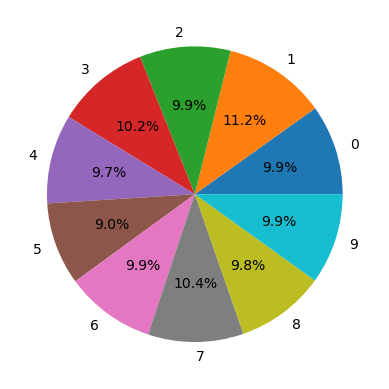

In [5]:
import numpy as np
import matplotlib.pyplot as plt


unique_values,value_counts = np.unique(train_labels , return_counts=True)
plt.pie(value_counts,labels=unique_values,autopct='%1.1f%%')
plt.show()

In [6]:
print(train_images[0].shape)

(28, 28)


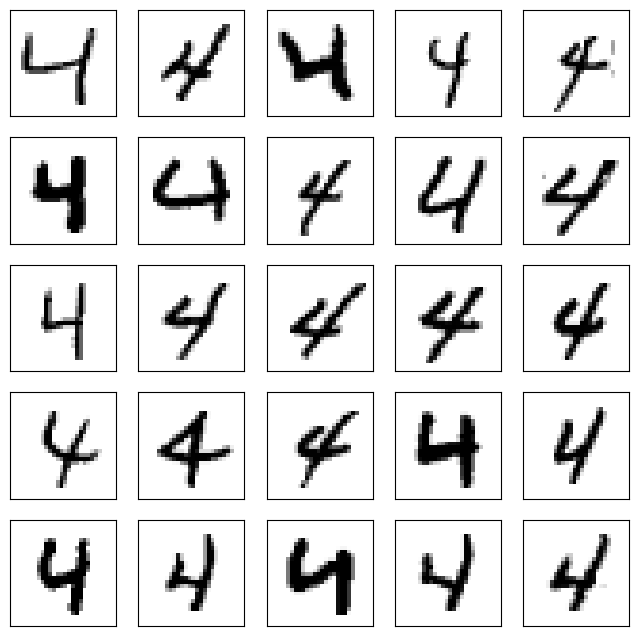

In [7]:
max_4 =25
images_4 = []

for i in range(len(train_labels)):
    if train_labels[i] == 4 :
        images_4.append(train_images[i])

        if len(images_4) == max_4:
            break

rows = 5
cols = 5

plt.figure(figsize=(8,8))

for i in range(max_4):
    plt.subplot(rows,cols,i+1)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(images_4[i],cmap=plt.cm.binary)
plt.show()

In [8]:
train_images = train_images / 255.0
test_images = test_images / 255.0

model = tk.Sequential([
    tk.layers.Flatten(input_shape=(28, 28)),
    tk.layers.Dense(units=512, activation='relu'),
    tk.layers.Dense(units=256, activation='relu'),
    tk.layers.Dense(units=128, activation='relu'),
    tk.layers.Dense(units=10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/home/abdulrahman/anaconda3/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-10-23 21:27:10.891316: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-10-23 21:27:10.891340: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2025-10-23 21:27:10.891346: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-10-23 21:27:10.891350: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or 

In [9]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9401 - loss: 0.1975
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9733 - loss: 0.0867
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9801 - loss: 0.0622 
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9847 - loss: 0.0490
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9886 - loss: 0.0364
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9895 - loss: 0.0339
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9911 - loss: 0.0297
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - accuracy: 0.9918 - loss: 0.0251
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9936 - loss: 0.0217
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9934 - loss: 0.0225


In [10]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9825 - loss: 0.0777       
Test accuracy: 0.9825000166893005


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  


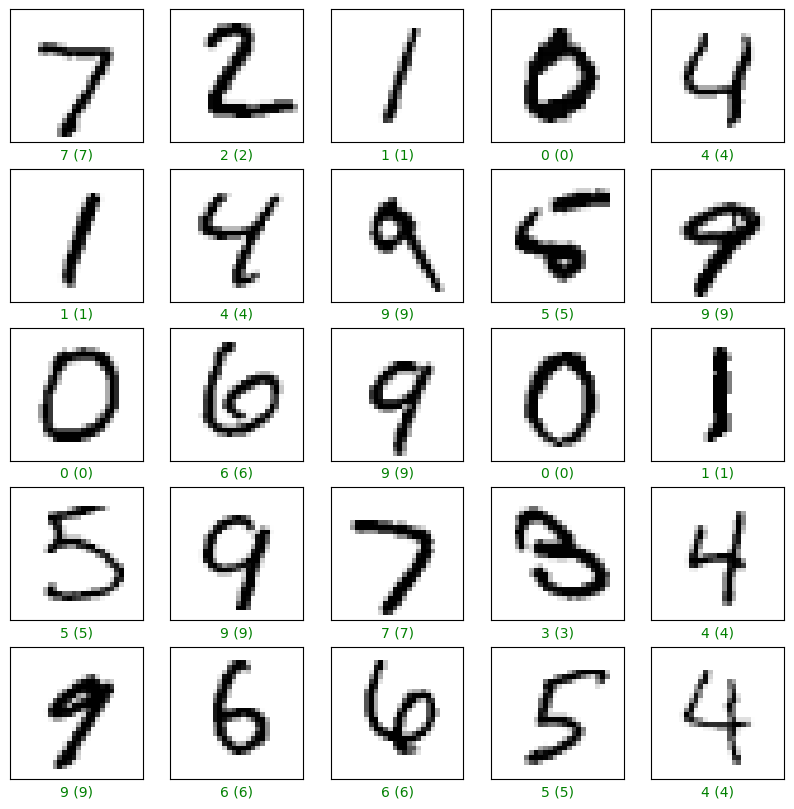

In [11]:
predictions = model.predict(test_images)

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i], cmap=plt.cm.binary)
    
    predicted_label = np.argmax(predictions[i])
    
    true_label = test_labels[i]
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'
    plt.xlabel("{} ({})".format(predicted_label, true_label), color=color)
plt.show()